In [ ]:

import optuna
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from main_files.trainer import prepare_data
from data_loader import load_stock
from features import create_features
from sklearn.model_selection import TimeSeriesSplit

In [2]:
def get_model_category(trial, model_type):
    if model_type == "xgb":
        model = XGBRegressor(n_estimators = trial.suggest_int("n_estimators", 100, 1000), max_depth = trial.suggest_int("max_depth", 1, 15), learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1), subsample = trial.suggest_float("subsample", 0.5, 1.0), colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0), random_state = 42)
    elif model_type == "lgb":
        model = LGBMRegressor(n_estimators = trial.suggest_int("n_estimators", 100, 1000), max_depth = trial.suggest_int("max_depth", 1, 15), learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1), subsample = trial.suggest_float("subsample", 0.5, 1.0), colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0), random_state = 42)
    elif model_type == "rf":
        model = RandomForestRegressor(n_estimators=trial.suggest_int("n_estimators", 100, 1000), max_depth=trial.suggest_int("max_depth", 1, 15), min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),min_samples_split=trial.suggest_int("min_samples_split", 2, 10), random_state=42)
    return model




In [ ]:
#df = load_stock('MSFT')

[*********************100%***********************]  1 of 1 completed


In [ ]:
#df = create_features(df)
#X_train, X_test, y_train, y_test = prepare_data(df)

In [5]:
def tune_model(model_type, X_train, y_train, X_test, y_test, n_trials=10):
    def objective(trial):
        model = get_model_category(trial, model_type)
        tscv = TimeSeriesSplit(n_splits = 5)
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr = X_train.iloc[train_idx]
            y_tr = y_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]
            y_val = y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        
        return np.mean(scores)
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    return study


In [6]:
def best_model(X_train, y_train, X_test, y_test):
    studies={}
    studies['rf'] = tune_model('rf' , X_train, y_train, X_test, y_test)
    studies['xgb'] = tune_model('xgb', X_train, y_train, X_test, y_test)
    studies['lgb'] = tune_model('lgb', X_train, y_train, X_test, y_test)
    
    best_type = min(studies, key=lambda x: studies[x].best_value)
    best_rmse = studies[best_type].best_value
    best_params = studies[best_type].best_params
    return best_type, best_params, best_rmse
  

In [ ]:
#best_type , best_params, best_rmse = best_model(X_train, y_train, X_test, y_test)
#print(best_params)
#print(best_rmse)
#print(best_type)

[I 2026-06-17 22:55:42,867] A new study created in memory with name: no-name-054090e0-f617-44cd-8842-c4e4dd656bd7


[I 2026-06-17 22:56:59,115] Trial 0 finished with value: 0.038340832564935194 and parameters: {'n_estimators': 836, 'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 3}. Best is trial 0 with value: 0.038340832564935194.
[I 2026-06-17 22:58:16,913] Trial 1 finished with value: 0.038589493303241906 and parameters: {'n_estimators': 646, 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 2}. Best is trial 0 with value: 0.038340832564935194.
[I 2026-06-17 22:58:31,545] Trial 2 finished with value: 0.03863789475941443 and parameters: {'n_estimators': 125, 'max_depth': 12, 'min_samples_leaf': 6, 'min_samples_split': 9}. Best is trial 0 with value: 0.038340832564935194.
[I 2026-06-17 23:00:20,560] Trial 3 finished with value: 0.03897912473170508 and parameters: {'n_estimators': 747, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 3}. Best is trial 0 with value: 0.038340832564935194.
[I 2026-06-17 23:01:17,452] Trial 4 finished with value: 0.0371658351922607 and

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 900
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 15
[LightGBM] [Info] Start training from score 0.003672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

[I 2026-06-17 23:04:39,433] Trial 0 finished with value: 0.04090112422025838 and parameters: {'n_estimators': 488, 'max_depth': 14, 'learning_rate': 0.023411418340530756, 'subsample': 0.5482915481281938, 'colsample_bytree': 0.7515637517879734}. Best is trial 0 with value: 0.04090112422025838.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 900
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 15
[LightGBM] [Info] Start training from score 0.003672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-06-17 23:06:40,308] Trial 8 finished with value: 0.042683029042621744 and parameters: {'n_estimators': 884, 'max_depth': 1, 'learning_rate': 0.09389566522460875, 'subsample': 0.5940673738464576, 'colsample_bytree': 0.9958671290133877}. Best is trial 0 with value: 0.04090112422025838.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-06-17 23:06:55,290] Trial 9 finished with value: 0.041238395241871006 and parameters: {'n_estimators': 870, 'max_depth': 15, 'learning_rate': 0.025211170468017064, 'subsample': 0.9794431356605291, 'colsample_bytree': 0.5803401608038801}. Best is trial 0 with value: 0.04090112422025838.


{'n_estimators': 520, 'max_depth': 4, 'min_samples_leaf': 7, 'min_samples_split': 9}
0.0371658351922607
rf


In [ ]:
def create_best_model(best_type , best_params):
    if best_type == 'xgb':
        model = XGBRegressor(**best_params, random_state=42)
    elif best_type == 'lgb':
        model = LGBMRegressor(**best_params, random_state=42)
    elif best_type == 'rf':
        model = RandomForestRegressor(**best_params, random_state=42)
    return model
#winner = create_best_model(best_type, best_params)
#winner.fit(X_train, y_train)
#y_pred = winner.predict(X_test)
#final_score = np.sqrt(mean_squared_error(y_test, y_pred))
#print(f'Final Score: {final_score}')



Final Score: 0.0445330740997733


In [ ]:
import pandas as pd
#model = winner
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

          Feature  Importance
6      Volatality    0.311915
1           Close    0.181927
9     MACD_Signal    0.132166
8            MACD    0.126262
7             RSI    0.046360
0        Momentum    0.035333
2          Volume    0.031745
5       Return_10    0.031189
14          Lag_5    0.022745
11          Lag_1    0.018900
3          Return    0.018366
4        Return_5    0.016271
12          Lag_2    0.010170
10  Volume_change    0.009148
13          Lag_3    0.007504


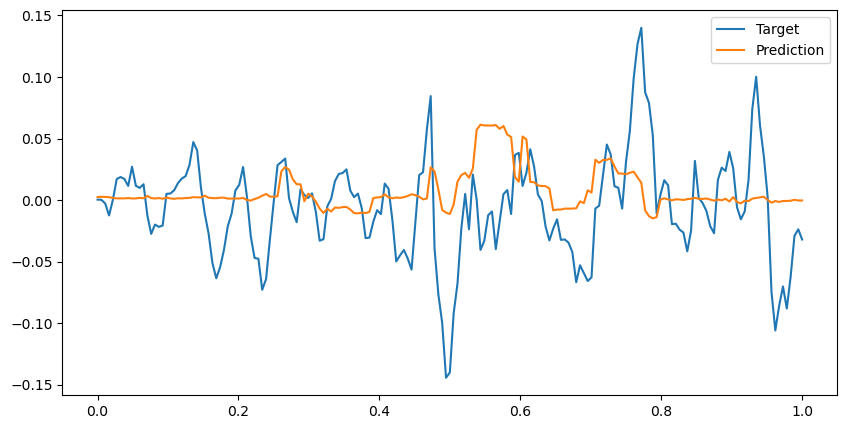

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot( np.linspace(0,1,len(y_test)), y_test, label='Target')
plt.plot(np.linspace(0,1,len(y_pred)), y_pred , label='Prediction')
plt.legend()
plt.show()

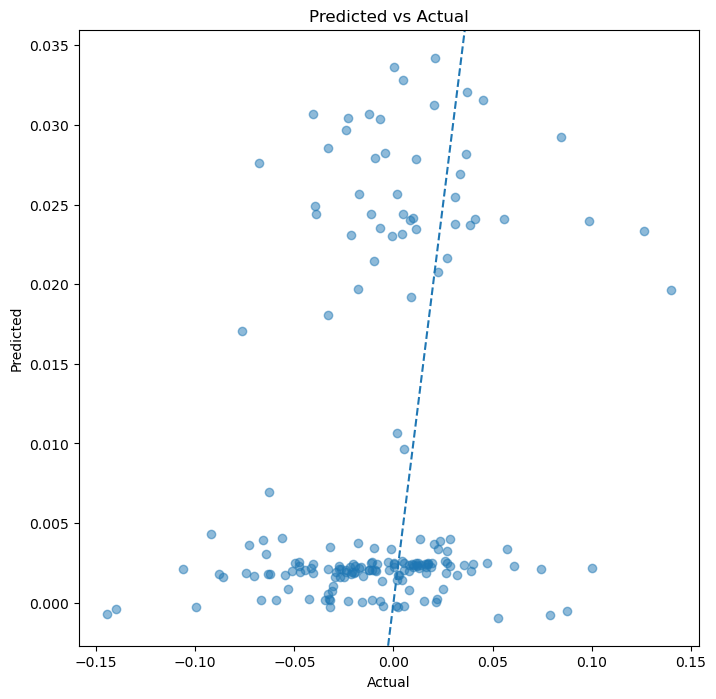

In [12]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Predicted vs Actual")

plt.axline(
    (0,0),
    slope=1,
    linestyle="--"
)

plt.show()

In [12]:


direction_acc = np.mean(
    np.sign(y_test)
    ==
    np.sign(y_pred)
)

print(
    "Direction Accuracy:",
    direction_acc

)

Direction Accuracy: 0.5837837837837838


In [14]:
print(np.std(y_test))
print(np.std(y_pred))

0.04171075668403581
0.01064526787692342
